# Training an RL agent with intrinsic motivation in a `MiniGrid` grid world
The goal of this notebook is to repeat and extend the analyses from `exp002`, but to construct our gridworld in [MiniGrid](https://minigrid.farama.org/) instead, in order to make our setup closer to other common RL experiments to increase reproducibility. Additionally, this time we not only compare empowerment to information gain, but also try first naive ways to combine them (empowerment + info gain, empowerment * info gain), and on top of that compare to novelty, a popular and often simple yet effective baseline in the intrinsic motivation literature.

> Note: Rather than running directly in the notebook, the agents were trained with the following commands:
> 1. `conda activate $WORK/conda_envs/empower`
> 2. `cd $WORK/empowerment-and-human-behavior/src`
> 3. `python generate_job_scripts.py`
> 4. `cd ..`
> 5. `./submit_all.sh`
> 
> which runs `run_single_agent.py` with various parameter combinations. To run one type of agent individually, simply run e.g. 
> 
> `python3 /mnt/lustre/work/wu/wkn758/empowerment-and-human-behavior/src/run_single_agent.py --agent ps --rewards empowerment --gamma 0.999 --q-init 0.0 --seed 63`

## Table of contents
1. [Running (or analyzing) individual agents](#individual-analysis)
2. [Analyzing mutltiple runs](#combined-analysis)

---

## 1. Running (or analyzing) individual agents <a name="individual-analysis"></a>

For this, we first need to define a custom MiniGrid environment, because the regular MiniGrid does not implement any states with stochastic transitions. We have defined a simple custom `MiniGridEnv` in `environment.py`, a `MiniGridEnvWithIce`. We also provide a specific instance of this env with a couple of interesting features (see images further below):
* The agent starts in a walled-off room in the upper right corner and with only one exit
* If it exits the room, it quickly faces lava, which it should not step into, or otherwise it will die and be reset back to the starting state in the room
* There is a large safe area without ice and lava to explore in the bottom right corner - but to get there, the agent has to either 
    * take the longer path around the ice patch, or 
    * take a risky shortcut through it, where it could slip into lava

We can verify that the environment works as expected by wrapping it in a `ImgObsWrapper` and rendering the entire environment to visualize the effects of a couple actions by the agent:

In [1]:
# Enable imports from src directory
import sys
sys.path.append('../src')

# Enable autoreload so that changes in source files are automatically reloaded
# when running any code in this notebook
%load_ext autoreload
%autoreload 2

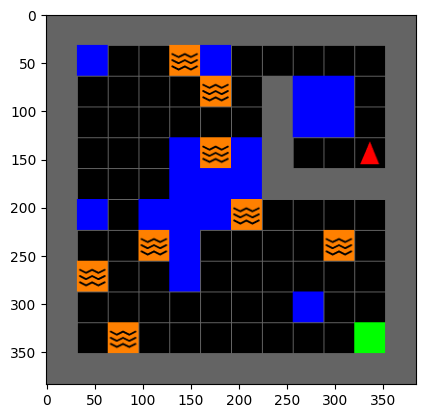

Action: forward
0 False False


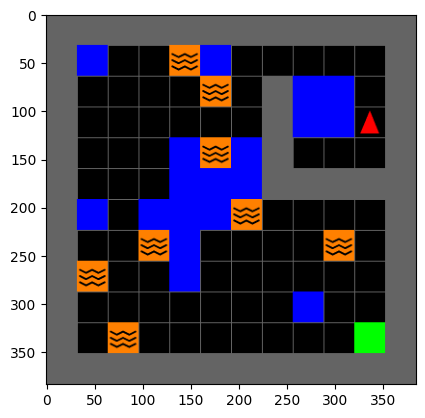

Action: forward
0 False False


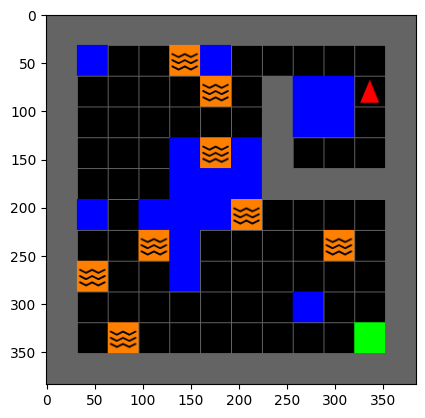

In [3]:
# visualize a sequence of actions in the slippery environment to see the if the agent "slips" correctly
import numpy as np
import matplotlib.pyplot as plt

from minigrid.wrappers import ImgObsWrapper
from environment import MixedEnv

env = MixedEnv(render_mode="rgb_array", highlight=False)
env = ImgObsWrapper(env)

env.reset(seed=0)
img = env.render()
plt.imshow(img)
plt.show()

from minigrid.core.actions import Actions
MINIGRID_ACTIONS = Actions 

actions = [MINIGRID_ACTIONS.forward, 
           MINIGRID_ACTIONS.forward, 
           MINIGRID_ACTIONS.forward, 
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.left, 
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.forward, 
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.forward, 
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.left,
           MINIGRID_ACTIONS.forward, 
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.right,
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.left,
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.forward,
           MINIGRID_ACTIONS.left,
           MINIGRID_ACTIONS.forward,
           ]

for action in actions[:2]:
    print(f"Action: {action.name}")
    obs, reward, terminated, truncated, _ = env.step(action)
    print(reward, terminated, truncated)
    if terminated:
        print("Terminated")
        env.reset()
    img = env.render()
    plt.imshow(img)
    plt.show()

In [4]:
# env.reset(seed=0)
# img = env.render()
# plt.imshow(img)
# plt.show()

# from minigrid.core.actions import Actions
# MINIGRID_ACTIONS = Actions 

# actions = [MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.left, 
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.left,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.right,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.left,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.left,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.forward,
#            MINIGRID_ACTIONS.right,
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.left, 
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward, 
#            MINIGRID_ACTIONS.forward, 
#            ]

# for action in actions:
#     print(f"Action: {action.name}")
#     obs, reward, terminated, truncated, _ = env.step(action)
#     print(reward, terminated, truncated)
#     if terminated:
#         print("Terminated")
#         env.reset()
#     img = env.render()
#     plt.imshow(img)
#     plt.show()

We can see above that the environment works as expected: The agent
* dies when falling into lava
* cannot walk through walls
* and most importantly, **slips in a random direction when moving on ice!**

To repeat the analyses in `exp002`, we need one more thing: a simpler observation. Ideally, we would like to use coordinates only as in our previous grid world, since that makes visualization easy, but in `MiniGrid` we also need to know which way we are pointing. Thus, our simple observation will consist of `(x, y, direction)` tuples: 

In [5]:
from environment import AgentPosAndDirWrapper

env = MixedEnv()
env = AgentPosAndDirWrapper(env)
ob, _ = env.reset(seed=0)
ob

(10, 4, 3)

In [6]:
ob, _, _, _, _ = env.step(MINIGRID_ACTIONS.forward)
ob

(10, 3, 3)

In [13]:
ob, _, _, _, _ = env.step(MINIGRID_ACTIONS.right)
ob

(10, 3, 0)

In [14]:
ob, _, _, _, _ = env.step(MINIGRID_ACTIONS.right)
ob

(10, 3, 1)

In [15]:
ob, _, _, _, _ = env.step(MINIGRID_ACTIONS.right)
ob

(10, 3, 2)

In [16]:
ob, _, _, _, _ = env.step(MINIGRID_ACTIONS.right)
ob

(10, 3, 3)

Now that we have verified that this also works as expected, we have an environment we can use to finally train our agent and run the same analyses as previously. We only need to reflect the fact that we not only use coordinates, but instead also have the direction (which we cannot visualize in the same way as before - so in order to create similar visualizations as before, we will average each quantity that we compute over the direction)

In [ ]:
# some plotting utils 
from visualization import plot_gridworld_and_heatmap, plot_learning_curves

In [18]:
# load utils
import dill as pickle
import os

def generate_run_identifier(params):
    """Generate unique identifier for parameter combination."""
    agent_name = "PrioritizedSweepingAgent"
    if len(params['rewards']) == 0:
        rewards_str = "none"
    else: 
        rewards_str = "_".join(params['rewards'])
    
    run_id = f"{agent_name}-reward_{rewards_str}"
    
    if len(params['rewards']) > 1:
        run_id += f"-{params['combination_method']}"
    
    run_id += f"-gamma_{float(params['gamma'])}-lr_{float(params['learning_rate'])}-qinit_{float(params['q_init'])}"
    run_id += f"-nsteps_{params['n_steps']}-eval_{params['eval_interval']}"
    run_id += f"-seed_{params['seed']}"

    if params['rewards'] and "empowerment" in params['rewards']:
        print("TODO: manually adding -emp_steps_1 for now, need to fix this!")
        run_id += f"-emp_steps_1"

    run_id += f"-{params['custom_identifier']}"

    return run_id

def load_single_run(params, base_path="/mnt/lustre/work/wu/wkn758/empowerment-and-human-behavior/dat/toy_env_runs"):
    """Load a single run as specified by the parameters."""
    
    run_id = generate_run_identifier(params)
    filename = os.path.join(base_path, f"{run_id}.pkl")
    
    try:
        with open(filename, 'rb') as f:
            history = pickle.load(f)
            return history
    except FileNotFoundError:
        raise FileNotFoundError(f"Run with parameters {params} not found. File {filename} does not exist.")

In [13]:
# default params for most runs
from generate_job_scripts import RANDOM_SEEDS
N_STEPS = 10000
EVAL_INTERVAL = 100

## Model-based agent with prioritized sweeping
From `exp002` to here, we are trying to our setup more and more realistic. One problem with our earlier setup was using a `QAgent` that only does *model-free* Q-Learning, which is based upon the assumption that rewards are stationary - but we are mostly using intrinsic motivations as rewards, which change as the agent increases its knowledge and skills, so they can by highly nonstationary. Additionally, we have to learn a model anyway to compute the intrinsic motivation measures in the first place (apart for novelty), so why not make use of it and switch to a *model-based* approach? 

Inspired by [Merits of curiosity: A simulation study](https://github.com/gruaz-lucas/Merits_of_curiosity/blob/main/src/agent.py), we use an agent that globally updates Q-values using its knowledge from the learned model, instead of only doing local updates based on TD-error. To be more precise, it computes new Q-values with the following update:

$$
Q(s,a) = \sum_{s^\prime \in \mathcal{S}} p(s^\prime|s,a) \left[R(s,a,s^\prime) + (1 - p_{\text{terminated}}(s^\prime|s,a)) \gamma \max_{a^\prime} Q(s^\prime,a^\prime) \right]
$$

where 
* $p(s^\prime|s,a)$ is approximated by our learned `CountBasedTransitionModel` $T(s,a,s^\prime)$, 
* $p_{\text{terminated}}(s^\prime|s,a)$ models the probability of observing the `terminated` flag, i.e. the episode ending due to termination, and is also approximated through counting
* $R(s,a,s')$ is a reward model (which so far simply is an array of size $(|S|, |A|, |S|)$ that stores the most recently experienced rewards for each $(s,a,s')$ tuple to avoid having to unnecessarily recompute all rewards at each step, nothing else. We do not do any sliding window average or anything yet, since that is not necessary for the intrinsic rewards, only for the extrinsic ones.)

In [14]:
from run_utils import run_or_load
from agent import PrioritizedSweepingAgent

In [15]:
NUM_ACTIONS = 3

In [16]:
from environment import get_all_states

In [ ]:
(0.5)**(2/len(372))

In [21]:
# Create agent
all_states = get_all_states(env.unwrapped)

# GAMMA = (0.5)**(2/len(all_states))
GAMMA = 0.999
LR = 1.0
Q_INIT = 0.0

# Run training
REWARDS = ["novelty"] # ["info_gain", "empowerment"]
COMBINATION_METHOD = "mean"
N_STEPS = 10000
EVAL_INTERVAL = 100

print(GAMMA)

DEFAULT_REWARD_CFG = {
    "empowerment": {
        "num_steps": 1,
        "method": "blahut_arimoto",
    },
    "info_gain": {
        "method": "LittleSommerPIG"
    },
    "novelty": {}
}

model_kwargs  = {
    "reward_types": REWARDS,
    "reward_configs": DEFAULT_REWARD_CFG,
    "combination_method": COMBINATION_METHOD
    }

agent = PrioritizedSweepingAgent(
    num_actions=NUM_ACTIONS, 
    all_states=all_states,
    learning_rate=LR, 
    gamma=GAMMA, 
    q_init=Q_INIT, 
    model_kwargs = model_kwargs
    )

history = run_or_load(env, 
                      agent, 
                      rewards=REWARDS,
                      combination_method=COMBINATION_METHOD,
                      n_steps=N_STEPS, 
                      eval_interval=EVAL_INTERVAL, 
                      seed=RANDOM_SEEDS[1], 
                      use_true_model=False,
                      custom_identifier="final")

0.999
Updating rewards in first step
Reward components initialized in first step
Run exists: /mnt/lustre/work/wu/wkn758/empowerment-and-human-behavior/dat/toy_env_runs/PrioritizedSweepingAgent-reward_novelty-gamma_0.999-lr_1.0-qinit_0.0-nsteps_10000-eval_100-seed_28958-final.pkl, loaded history from file.


In [45]:
REWARDS = ["info_gain", "empowerment"] # ["info_gain", "empowerment"]
GAMMA = 0.999
LR = 1.0
Q_INIT = 0.0
params = {
    'agent': 'PrioritizedSweepingAgent',
    'rewards': REWARDS, 
    'combination_method': "mean",
    'gamma': GAMMA, 
    'learning_rate': LR, 
    'q_init': Q_INIT, 
    'n_steps': 10000, 
    'eval_interval': 100, 
    'seed': RANDOM_SEEDS[0],
    'custom_identifier': "final"}

history = load_single_run(params)

TODO: manually adding -emp_steps_1 for now, need to fix this!


In [ ]:
REWARDS = ["info_gain"]
GAMMA = 0.999
LR = 1.0
Q_INIT = 0.0
params = {
    'agent': 'PrioritizedSweepingAgent',
    'rewards': REWARDS, 
    'gamma': GAMMA, 
    'learning_rate': LR, 
    'q_init': Q_INIT, 
    'n_steps': 100000, 
    'eval_interval': 1000, 
    'seed': RANDOM_SEEDS[0],
    'custom_identifier': "notdumb"}

history = load_single_run(params)

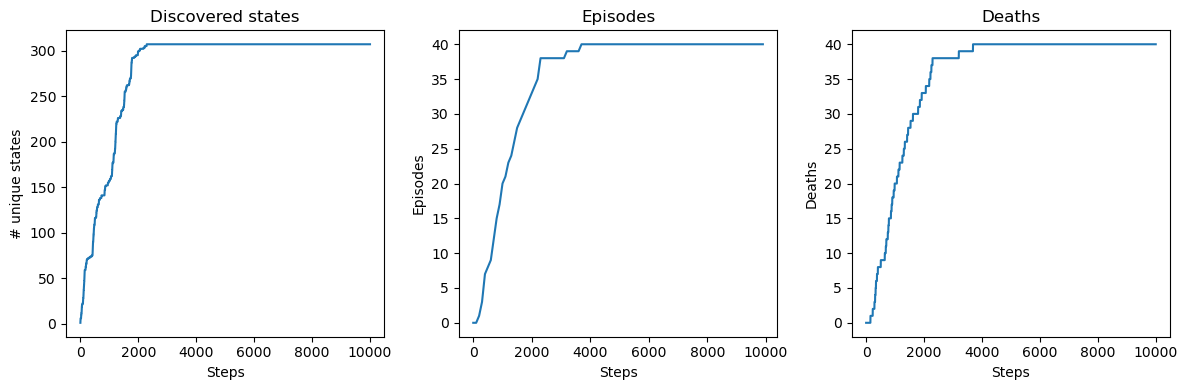

In [46]:
# Plot results
plot_learning_curves(history)
plt.show()

In [ ]:
# visualize where the agent spends time at different stages of training to understand whether it explores well or not
start_idx = (len(history['transitions']) * 900) // 1000
end_idx =  (len(history['transitions']) * 1000) // 1000

# add transition[0] (current state) and transition[2] (next state) 
agent_positions = [transition[2][:-1] for transition in history['transitions'][start_idx:end_idx]]
agent_positions = np.array(agent_positions)

# print transitions in this interval
# for transition in history['transitions'][start_idx:end_idx]:
#    coord = transition[0][:-1]
#    
    # check if coord is registered as lava in minigrid
#    cell = env.unwrapped.grid.get(*coord)
#    if cell != None and cell.type == "lava":
#        print("Lava!!")

#    print(transition)#

# pad counts to all positions
agent_pos_counts = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in agent_positions:
    if np.isnan(agent_pos_counts[x, y]):
        agent_pos_counts[x, y] = 1
    else:
        agent_pos_counts[x, y] += 1

# plot the agent's position as a heatmap
plot_gridworld_and_heatmap(env, agent_pos_counts, f'Agent position counts from step {start_idx} to {end_idx}', 'Counts')
plt.show()

In [50]:
from scipy.special import softmax
from novelty import compute_novelty_for_state
import os
import numpy as np
import itertools

def visualize_agent_state(env, history, eval_idx, gamma=None, lr=None, q_init=None, rewards=None, figsize=(6, 6), show_individual_figs=False, save_figs=False, save_path="../fig/"):
    """
    Visualize complete analysis of agent state at given evaluation step.
    
    Args:
        env: MiniGrid environment
        history: Dict containing training history
        eval_idx: Which evaluation step to visualize
        gamma, lr, q_init, rewards: Optional parameters for title
        figsize: Figure size as (width, height) for individual plots
        show_individual_figs: Whether to show individual figures or only the combined one
        save_figs: Whether to save the figures to disk
        save_path: Directory to save individual figures
    """
    
    if save_figs and not os.path.exists(save_path):
        os.makedirs(save_path)
        
    # Extract data
    estimated_empowerment = np.nanmean(history['empowerment_estimates'][eval_idx], axis=2)
    info_gain = np.nanmean(history['info_gain_estimates'][eval_idx], axis=2)
    try:
        novelty = np.nanmean(history['novelty_estimates'][eval_idx], axis=2)
    except KeyError:
        # recompute novelty with the model
        novelty = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
        model = history['transition_model'][eval_idx]
        for s in model.observed_states:
            x, y, dir = s
            novelty[x, y, dir] = compute_novelty_for_state(model.state_to_idx[s], model)
        novelty = np.nanmean(novelty, axis=2)


    q_values = history['q_values_per_state'][eval_idx]
    
    # Calculate policy entropies
    policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
    for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
        policies = softmax(q_values[x, y, :, :], axis=-1)
        policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))
    
    # Normalize entropy
    max_entropy = np.log(q_values.shape[-1])
    policy_entropies_normalized = policy_entropies / max_entropy
    
    # Normalize metrics
    emp_norm = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
    info_norm = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))
    
    # Calculate visit counts
    counts = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
    model = history['transition_model'][eval_idx]
    true_counts = (model.counts - model.prior_count) / model.update_strength
    for state, idx in model.state_to_idx.items():
        if np.isnan(counts[*state]):
            counts[*state] = 0
        counts[*state] += np.nansum(true_counts[idx])
    counts = np.nansum(counts, axis=2)

    # manually set counts to nan for wall cells
    for x in range(env.unwrapped.width):
        for y in range(env.unwrapped.height):
            cell = env.unwrapped.grid.get(x, y)
            if cell is not None and cell.type == "wall":
                counts[x, y] = np.nan
    
    # Prepare plot data
    plots = {
        'novelty': (novelty, 'Novelty'),
        'empowerment': (emp_norm, 'Empowerment'),
        'info_gain': (info_norm, 'Information Gain'),
        'emp_info_product': (emp_norm * info_norm, 'Product'),
        'emp_info_sum': (emp_norm + info_norm, 'Sum'),
        'visits': (counts, 'Visit Count'),
        'q_values': (np.nanmax(q_values, axis=(2, 3)), 'Max Q-Value'),
        'rewards': (np.nanmean(history['agent_rewards_through_model'][eval_idx], axis=(2, 3)), 'Reward'),
        'policy_entropy': (policy_entropies_normalized, 'Policy Entropy')
    }
    
    # Create individual figures
    figures = {}
    
    base_title = f"after {history['eval_steps'][eval_idx]+1} steps"
    if all(x is not None for x in [gamma, lr, q_init, rewards]):
        pass
        #base_title = f"(γ={gamma}, lr={lr}, q_init={q_init}, rewards={rewards}) {base_title}"

    def add_policy_arrows(ax, q_values):
        for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
            q_vals_for_coord = q_values[x, y, :, :]
            policies = softmax(q_vals_for_coord, axis=-1)
            max_prob_action = np.argmax(policies, axis=-1)
            
            for dir in range(4):  # 4 directions
                action = max_prob_action[dir]
                
                # Define arrow/action for each direction and action
                if dir == 0:  # facing right
                    dx, dy = 0.3, 0
                    symbol = 'L' if action == 0 else ('R' if action == 1 else '→')
                elif dir == 1:  # facing down
                    dx, dy = 0, 0.3
                    symbol = 'L' if action == 0 else ('R' if action == 1 else '↓')
                elif dir == 2:  # facing left
                    dx, dy = -0.3, 0
                    symbol = 'L' if action == 0 else ('R' if action == 1 else '←')
                else:  # facing up
                    dx, dy = 0, -0.3
                    symbol = 'L' if action == 0 else ('R' if action == 1 else '↑')
                
                ax.annotate(symbol, (x+dx, y+dy), 
                           color='black', ha='center', va='center', fontsize=15)
    
    if show_individual_figs or save_figs:
        for plot_name, (data, label) in plots.items():
            fig = plt.figure(figsize=figsize)
            ax = fig.add_subplot(111)
            
            # Plot heatmap
            plot_gridworld_and_heatmap(env, data, label, label, ax=ax)
            
            # Add policy arrows if this is the policy entropy plot
            if plot_name == 'q_values':
                add_policy_arrows(ax, q_values)
            
            # Style improvements
            # ax.set_title(f"{label} {base_title}", fontsize=12, pad=10)
            
            # Save figure
            fig.tight_layout()
            figures[plot_name] = fig
            if save_figs:
                filename = f"{plot_name}_step_{history['eval_steps'][eval_idx]}.png"
                fig.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
                plt.close(fig)
        
    
    # Create combined figure for reference
    fig_combined, axes = plt.subplots(3, 3, figsize=(20, 18))
    # fig_combined.suptitle(f"Combined Analysis {base_title}", fontsize=20)
    
    for (plot_name, (data, label)), ax in zip(plots.items(), axes.flatten()):
        plot_gridworld_and_heatmap(env, data, label, label, ax=ax)
        
        if plot_name == 'q_values':
            add_policy_arrows(ax, q_values)
    
    # Save combined figure
    fig_combined.tight_layout()

    if save_figs:
        filename = f"combined_analysis_step_{history['eval_steps'][eval_idx]}.png"
        fig_combined.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
        plt.close(fig_combined)
    else:
        plt.show()
    
    return figures

In [ ]:
# slightly different plotting function, used for cogsci paper to highlight the icons a bit more
import matplotlib as mpl
def plot_gridworld_and_heatmap(env, heatmap, title, colorbar_label, ax=None, env_type="minigrid"):
    if env_type == "minigrid":
        env = env.unwrapped
        
    # Set NaN values to grey in the colormap
    cmap = mpl.colormaps.get_cmap('viridis')
    cmap.set_bad(color='grey')
    
    def plot_cell_icon(ax, x, y, icon_type):
        """Plot cell icon with white fill and black outline"""
        icons = {
            "wall": "#",
            "ice": "❄",  # Using a different, cleaner snowflake symbol
            "lava": "☠",  # Unicode skull
            "portal": "○"
        }
        
        if icon_type in icons:
            fontsize = 25  # Increased font size
            fontweight = 'bold'
            outline_width = 0.7  # Increased outline width
            
            # For 'upper' origin, we need to flip the y coordinate
            if env_type == "minigrid":
                cell_center_y = (env.height - 1) - y
            else:
                cell_center_y = y
            cell_center_x = x

            # offset both by a tiny bit to center the icon
            cell_center_x -= 0.03
            cell_center_y -= 0.03
            
            # Create thicker outline by using more offset points
            outline_offsets = []
            for i in range(16):  # More points for smoother outline
                angle = 2 * np.pi * i / 16
                outline_offsets.append((np.cos(angle) * outline_width/30, 
                                     np.sin(angle) * outline_width/30))
            
            # Draw outline
            for dx, dy in outline_offsets:
                ax.text(cell_center_x + dx, 
                       cell_center_y + dy, 
                       icons[icon_type],
                       color='black',
                       ha='center',
                       va='center',
                       fontsize=fontsize,
                       fontweight=fontweight,
                       zorder=2,
                       family='DejaVu Sans')
            
            # Draw white text
            ax.text(cell_center_x, 
                   cell_center_y, 
                   icons[icon_type],
                   color='white',
                   ha='center',
                   va='center',
                   fontsize=fontsize,
                   fontweight=fontweight,
                   zorder=3,
                   family='DejaVu Sans')
    
    if ax is None:
        plt.figure(figsize=(7.5, 6))
        if env_type == "minigrid":
            im = plt.imshow(heatmap.T, origin='upper', interpolation='nearest', cmap=cmap,
                          extent=[-0.5, env.width-0.5, -0.5, env.height-0.5])
        elif env_type == "gridworld":
            im = plt.imshow(heatmap.T, origin='lower', interpolation='nearest', cmap=cmap,
                          extent=[-0.5, env.width-0.5, -0.5, env.height-0.5])
        else: 
            raise ValueError("env_type must be either 'minigrid' or 'gridworld'")
        
        ax = plt.gca()
    else:
        if env_type == "minigrid":
            im = ax.imshow(heatmap.T, origin='upper', interpolation='nearest', cmap=cmap,
                         extent=[-0.5, env.width-0.5, -0.5, env.height-0.5])
        elif env_type == "gridworld":
            im = ax.imshow(heatmap.T, origin='lower', interpolation='nearest', cmap=cmap,
                         extent=[-0.5, env.width-0.5, -0.5, env.height-0.5])
        else:
            raise ValueError("env_type must be either 'minigrid' or 'gridworld'")

    # Remove default grid
    ax.grid(False)
    
    # Add only the black grid lines
    ax.set_xticks(np.arange(-0.5, env.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.height, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
    
    # Remove major ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Plot icons
    if env_type == "minigrid":
        for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
            cell = env.grid.get(x, y)
            if cell is not None:
                if cell.type == "wall":
                    pass
                elif cell.type == "ice":
                    plot_cell_icon(ax, x, y, "ice")
                elif cell.type == "lava":
                    plot_cell_icon(ax, x, y, "lava")
    elif env_type == "gridworld":
        for x, y in env.obstacles:
            plot_cell_icon(ax, x, y, "wall")
        for x, y in env.ice_states:
            plot_cell_icon(ax, x, y, "ice")
        for x, y in env.death_states:
            plot_cell_icon(ax, x, y, "lava")
        for x, y in env.portals:
            plot_cell_icon(ax, x, y, "portal")
    
    if ax is None:
        plt.colorbar(im, label=colorbar_label)
        plt.title(title)
        plt.show()
    else:
        plt.colorbar(im, label=colorbar_label, ax=ax)
        ax.set_title(title)
        return ax

/tmp/ipykernel_678391/743836185.py:26: RuntimeWarning: Mean of empty slice
  estimated_empowerment = np.nanmean(history['empowerment_estimates'][eval_idx], axis=2)
/tmp/ipykernel_678391/743836185.py:27: RuntimeWarning: Mean of empty slice
  info_gain = np.nanmean(history['info_gain_estimates'][eval_idx], axis=2)
/tmp/ipykernel_678391/743836185.py:29: RuntimeWarning: Mean of empty slice
  novelty = np.nanmean(history['novelty_estimates'][eval_idx], axis=2)
/tmp/ipykernel_678391/743836185.py:46: RuntimeWarning: Mean of empty slice
  policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))
/tmp/ipykernel_678391/743836185.py:81: RuntimeWarning: All-NaN slice encountered
  'q_values': (np.nanmax(q_values, axis=(2, 3)), 'Max Q-Value'),
/tmp/ipykernel_678391/743836185.py:82: RuntimeWarning: Mean of empty slice
  'rewards': (np.nanmean(history['agent_rewards_through_model'][eval_idx], axis=(2, 3)), 'Reward'),


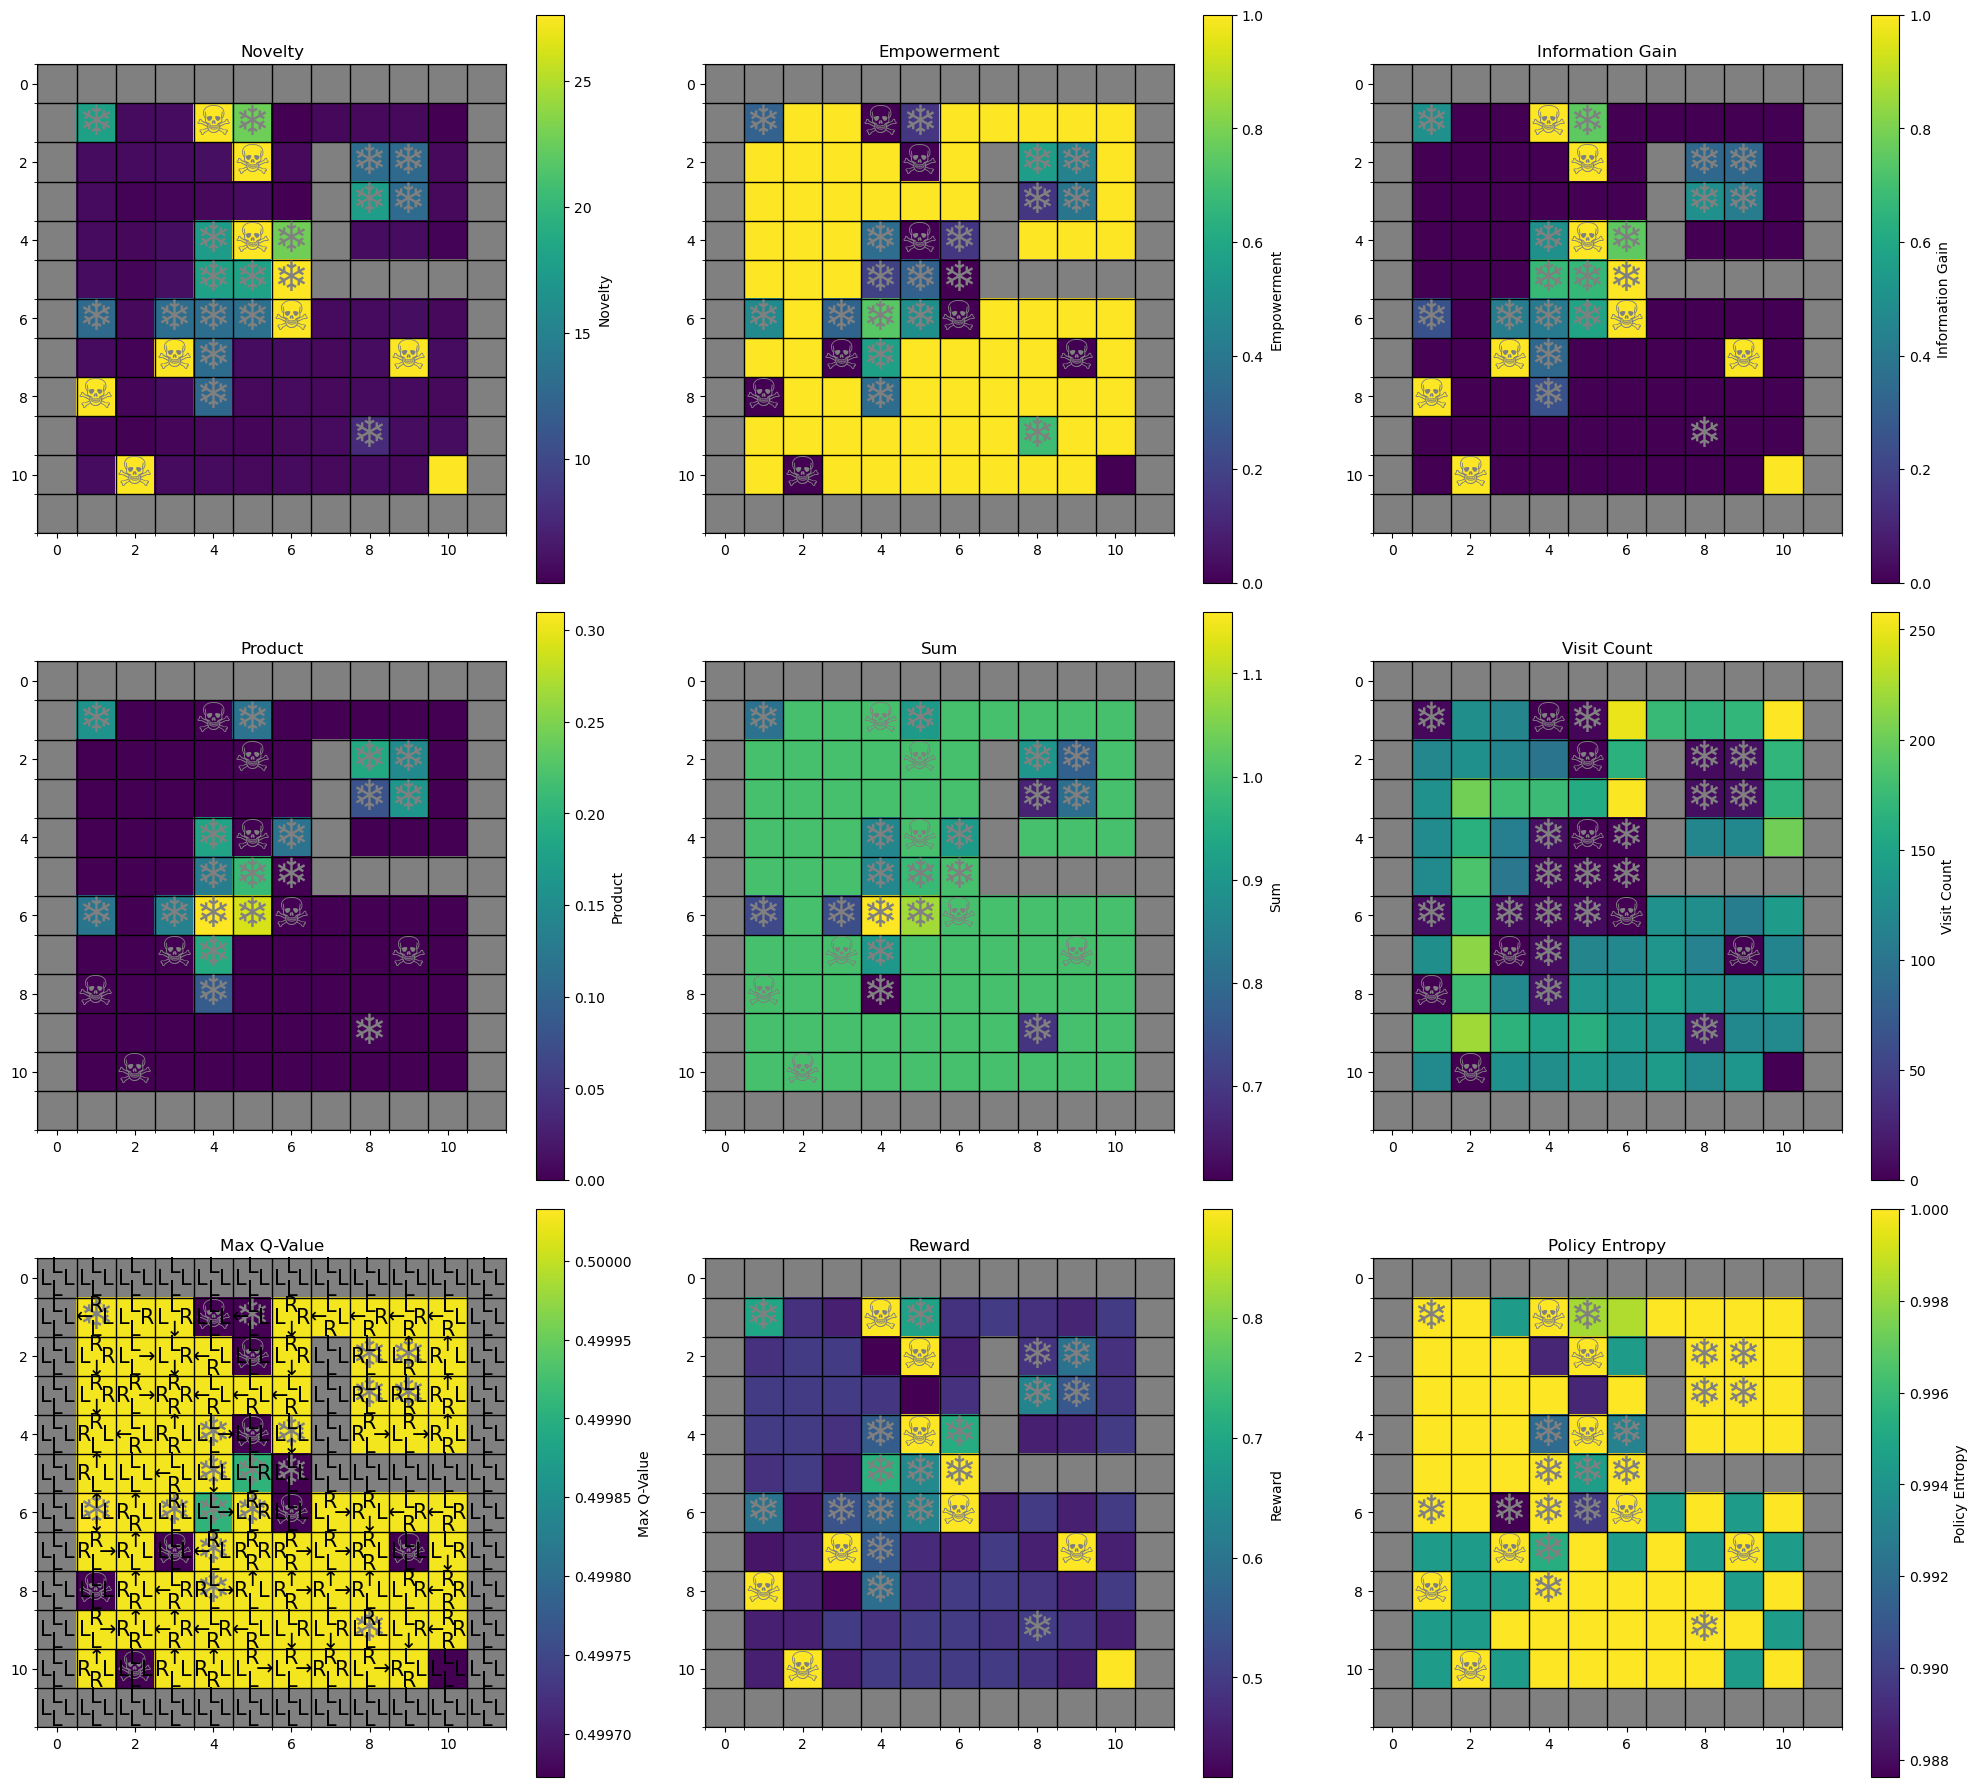

In [51]:
eval_idx = -1

figures = visualize_agent_state(
    env, 
    history, 
    eval_idx=eval_idx,
    gamma=GAMMA,
    lr=LR,
    q_init=Q_INIT,
    rewards=REWARDS,
    figsize=(5, 5),  # size for individual plots
)
plt.show()

In [ ]:
history['transitions']

In [ ]:
np.nanmax(history['empowerment_estimates'][eval_idx])

In [ ]:
history['empowerment_estimates'][eval_idx][3,9]

In [ ]:
history['empowerment_estimates'][eval_idx][1,1]

In [ ]:
# Extract data
estimated_empowerment = np.nanmean(history['empowerment_estimates'][eval_idx], axis=2)
info_gain = np.nanmean(history['info_gain_estimates'][eval_idx], axis=2)
try:
    novelty = np.nanmean(history['novelty_estimates'][eval_idx], axis=2)
except KeyError:
    # recompute novelty with the model
    novelty = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
    model = history['transition_model'][eval_idx]
    for s in model.observed_states:
        x, y, dir = s
        novelty[x, y, dir] = compute_novelty_for_state(model.state_to_idx[s], model)
    novelty = np.nanmean(novelty, axis=2)

q_values = history['q_values_per_state'][eval_idx]

# Calculate policy entropies
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    policies = softmax(q_values[x, y, :, :], axis=-1)
    policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))

# Normalize entropy
max_entropy = np.log(q_values.shape[-1])
policy_entropies_normalized = policy_entropies / max_entropy

# Normalize metrics
emp_norm = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
info_norm = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))

# Calculate visit counts
counts = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
model = history['transition_model'][eval_idx]
true_counts = (model.counts - model.prior_count) / model.update_strength
for state, idx in model.state_to_idx.items():
    if np.isnan(counts[*state]):
        counts[*state] = 0
    counts[*state] += np.nansum(true_counts[idx])
counts = np.nansum(counts, axis=2)


In [ ]:
history['agent_R'][eval_idx][model.state_to_idx[(10,3,2)]]

In [ ]:
1/372

In [ ]:
test_state_model_probs = model.get_full_transition_matrix()[0][model.state_to_idx[(5,1,2)], :, :]
test_state_model_probs

In [ ]:
# compute entropy of test_state_model_probs for each action
def compute_entropy(probs):
    """Compute entropy of a probability distribution."""
    return -np.sum(probs * np.log2(probs + 1e-10))

for i in range(3):
    print(compute_entropy(test_state_model_probs[i, :]))

In [ ]:
# print all nonzero entries of test_state_model_probs and their indices and corresponding values
nonzero_indices = np.nonzero(test_state_model_probs)
nonzero_values = test_state_model_probs[nonzero_indices]
nonzero_indices

In [ ]:
idx_to_state = {v: k for k, v in model.state_to_idx.items()}

for (action, idx), value in zip(zip(*nonzero_indices), nonzero_values):
    print(f"Action {action} - State: {idx_to_state[idx]}, Value: {value}")

In [ ]:
test_state_model_counts = model.get_true_counts()[model.state_to_idx[(5,1,2)], :, :]
test_state_model_counts

In [ ]:
test_state_model_counts.max()

In [ ]:
test_state_model_probs[0].max()

In [ ]:
history['agent_R'][eval_idx][model.state_to_idx[(10,3,2)], :, model.state_to_idx[(5,4,0)]]

In [ ]:
history['q_values_per_state'][eval_idx][8,1]

In [ ]:
history['q_values_per_state'][eval_idx][6,1]

In [ ]:
0.001 * 

In [ ]:
history['q_values_per_state'][eval_idx][10,3]

In [ ]:
history['q_values_per_state'][eval_idx][3,5,1]

In [ ]:
softmax(history['q_values_per_state'][eval_idx][3,5,1] / 0.1)

In [ ]:
# find last transition where agent died (transition[4] == True) 
# and print 20 transitions leading up to it
transitions = history['transitions']
counter = 0
for i in range(len(transitions)-1, -1, -1):
    if transitions[i][4] == True:
        counter += 1
        if counter == 1:
            print(f"{counter}-to-last transition where agent died:")
            print(f"Transition {i}:")
            for j in range(i-20, i+1):
                print(transitions[j])
            break

In [ ]:
history['agent_R'][eval_idx][model.state_to_idx[(10,4,0)]] > 0

In [ ]:
history['q_values_per_state'][eval_idx][10, 4]

In [ ]:
np.isnan(history['transition_model'][eval_idx].get_full_transition_matrix()[0]).any()

In [ ]:
# get 2d argmax of empowerment array
emp_max = np.unravel_index(np.nanargmax(estimated_empowerment), estimated_empowerment.shape)
emp_max

In [ ]:
estimated_empowerment[10,4]

In [ ]:
estimated_empowerment[3,9]

In [ ]:
q_values[10, 4]

In [ ]:
softmax(q_values[10, 4], axis=-1)

In [ ]:
fig = visualize_agent_state(env, history, eval_idx=50, gamma=GAMMA, lr=LR, q_init=Q_INIT, rewards=REWARDS)
plt.show()

In [ ]:
fig = visualize_agent_state(env, history, eval_idx=20, gamma=GAMMA, lr=LR, q_init=Q_INIT, rewards=REWARDS)
plt.show()

In [ ]:
# find 2d index of q-value in q_values with lowest value
min_q_value = np.nanmin(q_values)
min_q_value_idx = np.unravel_index(np.nanargmin(q_values), q_values.shape)
min_q_value_idx

In [ ]:
softmax(q_values[6, 2], axis=-1)

In [ ]:
model_idx_to_state = {idx: state for state, idx in model.state_to_idx.items()}

In [ ]:
model_idx_to_state[202]

In [ ]:
model.counts[model.state_to_idx[(6, 1, 2)]].max(axis=-1)

In [ ]:
transition_matrix, _ = model.get_full_transition_matrix()
transition_matrix[model.state_to_idx[(6, 1, 2)]].max(axis=-1)

In [ ]:
model.counts[model.state_to_idx[(6, 1, 2)]].argmax(axis=-1)

In [ ]:
q_values[6, 1]

In [ ]:
softmax(q_values[6, 1], axis=-1)

In [ ]:
# Create a figure showing all results
eval_idx = len(history['eval_steps']) // 4

estimated_empowerment = history['empowerment_estimates'][eval_idx]
info_gain = history['info_gain_estimates'][eval_idx]
novelty = history['novelty_estimates'][eval_idx]
q_values = history['q_values_per_state'][eval_idx] # array of shape (width, height, actions, directions)

# compute entropy of each softmax policy and average over directions
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # compute average entropy over directions
    policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))

# normalize this entropy: best (lowest) case is all zero except one direction with 1, worst (highest) case is all directions equally likely
max_entropy = np.log(q_values.shape[-1])
deterministic_dist = np.zeros(q_values.shape[-1])
deterministic_dist[0] = 1
best_case_policy = softmax(deterministic_dist)
min_entropy = -np.sum(best_case_policy * np.log(best_case_policy))
policy_entropies_normalized = (policy_entropies - min_entropy) / (max_entropy - min_entropy)

# average over directions
novelty = np.nanmean(novelty, axis=2)
estimated_empowerment = np.nanmean(estimated_empowerment, axis=2)
info_gain = np.nanmean(info_gain, axis=2)

# normalize both and compute difference & sum
estimated_empowerment_normalized = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
predicted_info_gain_normalized = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))
emp_info_gain_prod = estimated_empowerment_normalized * predicted_info_gain_normalized
emp_info_gain_sum = estimated_empowerment_normalized + predicted_info_gain_normalized

# get visitation count for each state
counts_matrix = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
model = history['transition_model'][eval_idx]
prior_count = model.prior_count
update_weight = model.update_strength
counts = model.counts # numpy array of shape (n_states, n_actions, n_states)
# compute actual counts for each transition by subtracting prior count for each next state and dividing by update weight
true_counts = (counts - prior_count) / update_weight
for state, idx in model.state_to_idx.items(): 
    if np.isnan(counts_matrix[*state]):
        counts_matrix[*state] = 0
    counts_matrix[*state] += np.nansum(true_counts[idx])
    
# Sum over directions to get a 2D array
counts_matrix = np.nansum(counts_matrix, axis=2)

# Get stored rewards in agent
agent_rewards = history['agent_rewards_through_model'][eval_idx] # shape (width, height, actions, 4)
agent_rewards = np.nanmean(agent_rewards, axis=(2, 3)) # average over actions and directions

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f"Analysis of Q-Learning agent (gamma={GAMMA}, lr={LR}, q_init={Q_INIT}) with rewards={REWARDS} after {history['eval_steps'][eval_idx]+1} steps", fontsize=20)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Prepare data tuples (data, title, colorbar_label)
plots_data = [
    (novelty, 'Novelty', 'Novelty'),
    (estimated_empowerment, 'Estimated Empowerment', 'Empowerment'),
    (info_gain, 'Predicted Information Gain', 'Information Gain'),
    (emp_info_gain_prod, 'Normalized Empowerment * Normalized Info Gain', 'Product'),
    (emp_info_gain_sum, 'Normalized Empowerment + Normalized Info Gain', 'Sum'),
    (counts_matrix, 'State Visitation Counts', 'Count'),
    (np.nanmax(q_values[:, :, :, MINIGRID_ACTIONS.forward], axis=2), 'Max "forward" Q-Value per Coordinate', 'Q-Value'),
    (agent_rewards, 'Agent Rewards', 'Reward'),
    (policy_entropies_normalized, 'Policy Entropy (normalized)', 'Normalized Entropy')
]

# Plot each subplot
for ax, (data, title, label) in zip(axes_flat, plots_data):
    plot_gridworld_and_heatmap(env, data, title, label, ax=ax)
    
# For most recent plot (Q-values), add arrow annotations to show the direction with the highest Q-value on the "forward" action
#for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
#    forward_q_values = q_values[x, y, :, MINIGRID_ACTIONS.forward]
#    if not np.isnan(forward_q_values).all():
#        max_direction = np.nanargmax(forward_q_values)
#        if max_direction == 0:
#            ax.annotate('→', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 1:
#            ax.annotate('↓', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 2:
#            ax.annotate('←', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 3: 
#            ax.annotate('↑', (x, y), color='black', ha='center', va='center', fontsize=20)
    
# Make another plot to visualize the highest probability action from policy and the policy entropy as a heatmap
# (should give some info which action is most likely for each state)
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # get max probability action in each direction
    max_prob_action = np.argmax(policies, axis=-1)
    max_action_probs = np.max(policies, axis=-1)
    
    
    # visualize max probability action in each direction (in each coordinate, plot a small arrow for each direction)
    for dir, action in enumerate(max_prob_action):
        if dir == 0:
            # agent is looking to direction "right"
            # plot annotation at the right side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. to the right)
                ax.annotate('→', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 1:
            # agent is looking to direction "down"
            # plot annotation at the bottom of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. down)
                ax.annotate('↓', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
        elif dir == 2:
            # agent is looking to direction "left"
            # plot annotation at the left side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. to the left)
                ax.annotate('←', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 3:
            # agent is looking to direction "up"
            # plot annotation at the top of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. up)
                ax.annotate('↑', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
q_values[10, 4]

In [ ]:
q_values[10, 1]

In [ ]:
transition_matrix, _ = model.get_full_transition_matrix()

In [ ]:
model.counts[model.state_to_idx[(10, 1, 0)]].max(axis=-1)

In [ ]:
transition_matrix[model.state_to_idx[(10, 1, 0)]].max(axis=-1)

In [ ]:
model_idx_to_state = {idx: state for state, idx in model.state_to_idx.items()}
[model_idx_to_state[idx] for idx in model.counts[model.state_to_idx[(6, 3, 0)]].argmax(axis=-1)]

In [ ]:
[model_idx_to_state[idx] for idx in transition_matrix[model.state_to_idx[(6, 3, 0)]].argmax(axis=-1)]

In [ ]:
agent_rewards = history['agent_rewards_through_model'][-1]
agent_rewards[1, 1]

In [ ]:
# Create a figure showing all results
eval_idx = len(history['eval_steps']) // 2

estimated_empowerment = history['empowerment_estimates'][eval_idx]
info_gain = history['info_gain_estimates'][eval_idx]
novelty = history['novelty_estimates'][eval_idx]
q_values = history['q_values_per_state'][eval_idx] # array of shape (width, height, actions, directions)

# compute entropy of each softmax policy and average over directions
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # compute average entropy over directions
    policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))

# normalize this entropy: best (lowest) case is all zero except one direction with 1, worst (highest) case is all directions equally likely
max_entropy = np.log(q_values.shape[-1])
deterministic_dist = np.zeros(q_values.shape[-1])
deterministic_dist[0] = 1
best_case_policy = softmax(deterministic_dist)
min_entropy = -np.sum(best_case_policy * np.log(best_case_policy))
policy_entropies_normalized = (policy_entropies - min_entropy) / (max_entropy - min_entropy)

# average over directions
novelty = np.nanmean(novelty, axis=2)
estimated_empowerment = np.nanmean(estimated_empowerment, axis=2)
info_gain = np.nanmean(info_gain, axis=2)

# normalize both and compute difference & sum
estimated_empowerment_normalized = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
predicted_info_gain_normalized = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))
emp_info_gain_prod = estimated_empowerment_normalized * predicted_info_gain_normalized
emp_info_gain_sum = estimated_empowerment_normalized + predicted_info_gain_normalized

# get visitation count for each state
counts_matrix = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
model = history['transition_model'][eval_idx]
prior_count = model.prior_count
update_weight = model.update_strength
counts = model.counts # numpy array of shape (n_states, n_actions, n_states)
# compute actual counts for each transition by subtracting prior count for each next state and dividing by update weight
true_counts = (counts - prior_count) / update_weight
for state, idx in model.state_to_idx.items(): 
    if np.isnan(counts_matrix[*state]):
        counts_matrix[*state] = 0
    counts_matrix[*state] += np.nansum(true_counts[idx])
    
# Sum over directions to get a 2D array
counts_matrix = np.nansum(counts_matrix, axis=2)

# Get stored rewards in agent
agent_rewards = history['agent_rewards_through_model'][eval_idx] # shape (width, height, actions, 4)
agent_rewards = np.nanmean(agent_rewards, axis=(2, 3)) # average over actions and directions

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f"Analysis of Q-Learning agent (gamma={GAMMA}, lr={LR}, q_init={Q_INIT}) with rewards={REWARDS} after {history['eval_steps'][eval_idx]+1} steps", fontsize=20)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Prepare data tuples (data, title, colorbar_label)
plots_data = [
    (novelty, 'Novelty', 'Novelty'),
    (estimated_empowerment, 'Estimated Empowerment', 'Empowerment'),
    (info_gain, 'Predicted Information Gain', 'Information Gain'),
    (emp_info_gain_prod, 'Normalized Empowerment * Normalized Info Gain', 'Product'),
    (emp_info_gain_sum, 'Normalized Empowerment + Normalized Info Gain', 'Sum'),
    (counts_matrix, 'State Visitation Counts', 'Count'),
    (np.nanmax(q_values[:, :, :, MINIGRID_ACTIONS.forward], axis=2), 'Max "forward" Q-Value per Coordinate', 'Q-Value'),
    (agent_rewards, 'Agent Rewards', 'Reward'),
    (policy_entropies_normalized, 'Policy Entropy (normalized)', 'Normalized Entropy')
]

# Plot each subplot
for ax, (data, title, label) in zip(axes_flat, plots_data):
    plot_gridworld_and_heatmap(env, data, title, label, ax=ax)
    
# For most recent plot (Q-values), add arrow annotations to show the direction with the highest Q-value on the "forward" action
#for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
#    forward_q_values = q_values[x, y, :, MINIGRID_ACTIONS.forward]
#    if not np.isnan(forward_q_values).all():
#        max_direction = np.nanargmax(forward_q_values)
#        if max_direction == 0:
#            ax.annotate('→', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 1:
#            ax.annotate('↓', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 2:
#            ax.annotate('←', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 3: 
#            ax.annotate('↑', (x, y), color='black', ha='center', va='center', fontsize=20)
    
# Make another plot to visualize the highest probability action from policy and the policy entropy as a heatmap
# (should give some info which action is most likely for each state)
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # get max probability action in each direction
    max_prob_action = np.argmax(policies, axis=-1)
    max_action_probs = np.max(policies, axis=-1)
    
    
    # visualize max probability action in each direction (in each coordinate, plot a small arrow for each direction)
    for dir, action in enumerate(max_prob_action):
        if dir == 0:
            # agent is looking to direction "right"
            # plot annotation at the right side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. to the right)
                ax.annotate('→', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 1:
            # agent is looking to direction "down"
            # plot annotation at the bottom of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. down)
                ax.annotate('↓', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
        elif dir == 2:
            # agent is looking to direction "left"
            # plot annotation at the left side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. to the left)
                ax.annotate('←', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 3:
            # agent is looking to direction "up"
            # plot annotation at the top of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. up)
                ax.annotate('↑', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
# import entropy
from scipy.stats import entropy

In [ ]:
entropy(softmax(q_values[2, 9], axis=-1), axis=-1)

In [ ]:
model_idx_to_state = {idx: state for state, idx in model.state_to_idx.items()}
model_idx_to_state[37]

In [ ]:
np.nanmin(q_values), np.nanmax(q_values)

In [ ]:
agent_R = history['agent_R'][eval_idx]
agent_R.min(), agent_R.max()

In [ ]:
q_values.reshape((-1, q_values.shape[2]))[model.stat]

In [ ]:
# compute Q[1, 10] as T[1, 10, 0] * (R[1, 10, 0] + gamma * max_a' Q[1, 10])
# reshape q-values with state_to_idx (from (x, y, dir, a) to (idx, a) where idx = state_to_idx[(x, y, d)])
q_values = history['q_values_per_state'][eval_idx]
model = history['transition_model'][eval_idx]

# get transition matrix and rewards
transition_matrix, _ = model.get_full_transition_matrix()
R = history['agent_R'][eval_idx]

# reshape Q
q_values_reshaped = np.zeros(transition_matrix.shape[:-1])
for state, idx in model.state_to_idx.items():
    for a in range(q_values.shape[-1]):
        x, y, dir = state
        q_values_reshaped[idx, a] = q_values[x, y, dir, a]

# compute Q[1, 10] as T[1, 10, 0] * (R[1, 10, 0] + gamma * max_a' Q[1, 10])
new_q = np.sum(transition_matrix * (R + 0.999 * np.max(q_values_reshaped, axis=-1).reshape(1, 1, -1)), axis=2)
q_1_10 = new_q[model.state_to_idx[(1, 10, 0)]]
q_1_10

In [ ]:
new_q 

In [ ]:
R[model.state_to_idx[(1, 10, 0)]]

In [ ]:
q_values_reshaped[model.state_to_idx[(1, 10, 0)]]

In [ ]:
new_q = np.clip(new_q, 0.0, 2/(1-0.999))
new_q = np.round(new_q, decimals=2) 

In [ ]:
new_q

In [ ]:
np.max(np.abs(np.max(q_values_reshaped, axis=-1) - np.max(new_q, axis=-1)))

In [ ]:
transition_matrix, _ = model.get_full_transition_matrix()
transition_matrix[model.state_to_idx[(1, 10, 0)]].argmax(axis=-1)

In [ ]:
agent_rewards[1, 10]

In [ ]:
R = history["agent_R"][eval_idx]
R

In [ ]:
R[model.state_to_idx[(1, 10, 0)]]

In [ ]:
softmax(q_values[1, 10], axis=-1)

In [ ]:
q_values[6, 3]

In [ ]:
# Create a figure showing all results
eval_idx = len(history['eval_steps']) - 1

estimated_empowerment = history['empowerment_estimates'][eval_idx]
info_gain = history['info_gain_estimates'][eval_idx]
novelty = history['novelty_estimates'][eval_idx]
q_values = history['q_values_per_state'][eval_idx] # array of shape (width, height, actions, directions)

# compute entropy of each softmax policy and average over directions
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # compute average entropy over directions
    policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))

# normalize this entropy: best (lowest) case is all zero except one direction with 1, worst (highest) case is all directions equally likely
max_entropy = np.log(q_values.shape[-1])
deterministic_dist = np.zeros(q_values.shape[-1])
deterministic_dist[0] = 1
best_case_policy = softmax(deterministic_dist)
min_entropy = -np.sum(best_case_policy * np.log(best_case_policy))
policy_entropies_normalized = (policy_entropies - min_entropy) / (max_entropy - min_entropy)

# average over directions
novelty = np.nanmean(novelty, axis=2)
estimated_empowerment = np.nanmean(estimated_empowerment, axis=2)
info_gain = np.nanmean(info_gain, axis=2)

# normalize both and compute difference & sum
estimated_empowerment_normalized = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
predicted_info_gain_normalized = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))
emp_info_gain_prod = estimated_empowerment_normalized * predicted_info_gain_normalized
emp_info_gain_sum = estimated_empowerment_normalized + predicted_info_gain_normalized

# get visitation count for each state
counts_matrix = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
model = history['transition_model'][eval_idx]
prior_count = model.prior_count
update_weight = model.update_strength
counts = model.counts # numpy array of shape (n_states, n_actions, n_states)
# compute actual counts for each transition by subtracting prior count for each next state and dividing by update weight
true_counts = (counts - prior_count) / update_weight
for state, idx in model.state_to_idx.items(): 
    if np.isnan(counts_matrix[*state]):
        counts_matrix[*state] = 0
    counts_matrix[*state] += np.nansum(true_counts[idx])
    
# Sum over directions to get a 2D array
counts_matrix = np.nansum(counts_matrix, axis=2)

# Get stored rewards in agent
agent_rewards = history['agent_rewards_through_model'][eval_idx] # shape (width, height, actions, 4)
agent_rewards = np.nanmean(agent_rewards, axis=(2, 3)) # average over actions and directions

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f"Analysis of Q-Learning agent (gamma={GAMMA}, lr={LR}, q_init={Q_INIT}) with rewards={REWARDS} after {history['eval_steps'][eval_idx]+1} steps", fontsize=20)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Prepare data tuples (data, title, colorbar_label)
plots_data = [
    (novelty, 'Novelty', 'Novelty'),
    (estimated_empowerment, 'Estimated Empowerment', 'Empowerment'),
    (info_gain, 'Predicted Information Gain', 'Information Gain'),
    (emp_info_gain_prod, 'Normalized Empowerment * Normalized Info Gain', 'Product'),
    (emp_info_gain_sum, 'Normalized Empowerment + Normalized Info Gain', 'Sum'),
    (counts_matrix, 'State Visitation Counts', 'Count'),
    (np.nanmax(q_values[:, :, :, MINIGRID_ACTIONS.forward], axis=2), 'Max "forward" Q-Value per Coordinate', 'Q-Value'),
    (agent_rewards, 'Agent Rewards', 'Reward'),
    (policy_entropies_normalized, 'Policy Entropy (normalized)', 'Normalized Entropy')
]

# Plot each subplot
for ax, (data, title, label) in zip(axes_flat, plots_data):
    plot_gridworld_and_heatmap(env, data, title, label, ax=ax)
    
# For most recent plot (Q-values), add arrow annotations to show the direction with the highest Q-value on the "forward" action
#for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
#    forward_q_values = q_values[x, y, :, MINIGRID_ACTIONS.forward]
#    if not np.isnan(forward_q_values).all():
#        max_direction = np.nanargmax(forward_q_values)
#        if max_direction == 0:
#            ax.annotate('→', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 1:
#            ax.annotate('↓', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 2:
#            ax.annotate('←', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 3: 
#            ax.annotate('↑', (x, y), color='black', ha='center', va='center', fontsize=20)
    
# Make another plot to visualize the highest probability action from policy and the policy entropy as a heatmap
# (should give some info which action is most likely for each state)
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # get max probability action in each direction
    max_prob_action = np.argmax(policies, axis=-1)
    max_action_probs = np.max(policies, axis=-1)
    
    
    # visualize max probability action in each direction (in each coordinate, plot a small arrow for each direction)
    for dir, action in enumerate(max_prob_action):
        if dir == 0:
            # agent is looking to direction "right"
            # plot annotation at the right side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. to the right)
                ax.annotate('→', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 1:
            # agent is looking to direction "down"
            # plot annotation at the bottom of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. down)
                ax.annotate('↓', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
        elif dir == 2:
            # agent is looking to direction "left"
            # plot annotation at the left side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. to the left)
                ax.annotate('←', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 3:
            # agent is looking to direction "up"
            # plot annotation at the top of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to go forward (i.e. up)
                ax.annotate('↑', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
softmax(q_values[5, 1])

In [ ]:
q_values[2, 6]

In [ ]:
q_values[6, 1]

In [ ]:
agent_rewards

In [ ]:
softmax(q_values[6, 1], axis=-1)

In [ ]:
# check what happens with softmax over maximum contrast in Q-values (all zeros except for one which is 1)
best_case_q_vals = np.array([0, 0, 1])
best_case_policy = softmax(best_case_q_vals, axis=-1)
worst_case_q_vals = np.array([0, 0, 0])
worst_case_policy = softmax(worst_case_q_vals, axis=-1)

# compute this best-case entropy vs the worst-case entropy
best_case_entropy = -np.sum(best_case_policy * np.log(best_case_policy))
worst_case_entropy = -np.sum(worst_case_policy * np.log(worst_case_policy))
best_case_entropy, worst_case_entropy

In [ ]:
agent_rewards = history['agent_rewards_through_model'][eval_idx]
agent_rewards[9, 2]

In [ ]:
print("HELLO CLUSTER PLEASE WAKE UP THANKS")

In [ ]:
# Create a figure showing all results
eval_idx = len(history['eval_steps']) - 1

estimated_empowerment = history['empowerment_estimates'][eval_idx]
info_gain = history['info_gain_estimates'][eval_idx]
q_values = history['q_values_per_state'][eval_idx] # array of shape (width, height, actions, directions)

# compute entropy of each softmax policy and average over directions
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # compute average entropy over directions
    policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))

# normalize this entropy: best (lowest) case is all zero except one direction with 1, worst (highest) case is all directions equally likely
max_entropy = np.log(q_values.shape[-1])
deterministic_dist = np.zeros(q_values.shape[-1])
deterministic_dist[0] = 1
best_case_policy = softmax(deterministic_dist)
min_entropy = -np.sum(best_case_policy * np.log(best_case_policy))
policy_entropies_normalized = (policy_entropies - min_entropy) / (max_entropy - min_entropy)

# average over directions
estimated_empowerment = np.nanmean(estimated_empowerment, axis=2)
info_gain = np.nanmean(info_gain, axis=2)

# normalize both and compute difference & sum
estimated_empowerment_normalized = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
predicted_info_gain_normalized = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))
emp_info_gain_prod = estimated_empowerment_normalized * predicted_info_gain_normalized
emp_info_gain_sum = estimated_empowerment_normalized + predicted_info_gain_normalized

# get visitation count for each state
counts_matrix = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
model = history['transition_model'][eval_idx]
prior_count = model.prior_count
update_weight = model.update_strength
counts = model.counts # numpy array of shape (n_states, n_actions, n_states)
# compute actual counts for each transition by subtracting prior count for each next state and dividing by update weight
true_counts = (counts - prior_count) / update_weight
for state, idx in model.state_to_idx.items(): 
    if np.isnan(counts_matrix[*state]):
        counts_matrix[*state] = 0
    counts_matrix[*state] += np.nansum(true_counts[idx])
    
# Sum over directions to get a 2D array
counts_matrix = np.nansum(counts_matrix, axis=2)

# Get stored rewards in agent
agent_rewards = history['agent_rewards_through_model'][eval_idx] # shape (width, height, actions, 4)
agent_rewards = np.nanmean(agent_rewards, axis=(2, 3)) # average over actions and directions

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f"Analysis of Q-Learning agent (gamma={GAMMA}, lr={LR}, q_init={Q_INIT}) with rewards={REWARDS} after {history['eval_steps'][eval_idx]+1} steps", fontsize=20)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Prepare data tuples (data, title, colorbar_label)
plots_data = [
    (estimated_empowerment, 'Estimated Empowerment', 'Empowerment'),
    (info_gain, 'Predicted Information Gain', 'Information Gain'),
    (emp_info_gain_prod, 'Normalized Empowerment * Normalized Info Gain', 'Product'),
    (emp_info_gain_sum, 'Normalized Empowerment + Normalized Info Gain', 'Sum'),
    (counts_matrix, 'State Visitation Counts', 'Count'),
    (np.nanmax(q_values[:, :, :, MINIGRID_ACTIONS.forward], axis=2), 'Max "forward" Q-Value per Coordinate', 'Q-Value'),
    (agent_rewards, 'Agent Rewards', 'Reward'),
    (policy_entropies_normalized, 'Policy Entropy (normalized)', 'Normalized Entropy')
]

# Plot each subplot
for ax, (data, title, label) in zip(axes_flat, plots_data):
    plot_gridworld_and_heatmap(env, data, title, label, ax=ax)
    
# For most recent plot (Q-values), add arrow annotations to show the direction with the highest Q-value on the "forward" action
#for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
#    forward_q_values = q_values[x, y, :, MINIGRID_ACTIONS.forward]
#    if not np.isnan(forward_q_values).all():
#        max_direction = np.nanargmax(forward_q_values)
#        if max_direction == 0:
#            ax.annotate('→', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 1:
#            ax.annotate('↓', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 2:
#            ax.annotate('←', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 3: 
#            ax.annotate('↑', (x, y), color='black', ha='center', va='center', fontsize=20)
    
# Make another plot to visualize the highest probability action from policy and the policy entropy as a heatmap
# (should give some info which action is most likely for each state)
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # get max probability action in each direction
    max_prob_action = np.argmax(policies, axis=-1)
    max_action_probs = np.max(policies, axis=-1)
    
    
    # visualize max probability action in each direction (in each coordinate, plot a small arrow for each direction)
    for dir, action in enumerate(max_prob_action):
        if dir == 0:
            # agent is looking to direction "right"
            # plot annotation at the right side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. to the right)
                ax.annotate('→', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 1:
            # agent is looking to direction "down"
            # plot annotation at the bottom of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. down)
                ax.annotate('↓', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
        elif dir == 2:
            # agent is looking to direction "left"
            # plot annotation at the left side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. to the left)
                ax.annotate('←', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 3:
            # agent is looking to direction "up"
            # plot annotation at the top of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. up)
                ax.annotate('↑', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)


# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Create a figure showing all results
eval_idx = len(history['eval_steps']) - 1

estimated_empowerment = history['empowerment_estimates'][eval_idx]
info_gain = history['info_gain_estimates'][eval_idx]
q_values = history['q_values_per_state'][eval_idx] # array of shape (width, height, actions, directions)

# compute entropy of each softmax policy and average over directions
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # compute average entropy over directions
    policy_entropies[x, y] = np.nanmean(-np.sum(policies * np.log(policies), axis=-1))

# normalize this entropy: best (lowest) case is all zero except one direction with 1, worst (highest) case is all directions equally likely
max_entropy = np.log(q_values.shape[-1])
deterministic_dist = np.zeros(q_values.shape[-1])
deterministic_dist[0] = 1
best_case_policy = softmax(deterministic_dist)
min_entropy = -np.sum(best_case_policy * np.log(best_case_policy))
policy_entropies_normalized = (policy_entropies - min_entropy) / (max_entropy - min_entropy)

# average over directions
estimated_empowerment = np.nanmean(estimated_empowerment, axis=2)
info_gain = np.nanmean(info_gain, axis=2)

# normalize both and compute difference & sum
estimated_empowerment_normalized = (estimated_empowerment - np.nanmin(estimated_empowerment)) / (np.nanmax(estimated_empowerment) - np.nanmin(estimated_empowerment))
predicted_info_gain_normalized = (info_gain - np.nanmin(info_gain)) / (np.nanmax(info_gain) - np.nanmin(info_gain))
emp_info_gain_prod = estimated_empowerment_normalized * predicted_info_gain_normalized
emp_info_gain_sum = estimated_empowerment_normalized + predicted_info_gain_normalized

# get visitation count for each state
counts_matrix = np.full((env.unwrapped.width, env.unwrapped.height, 4), np.nan)
model = history['transition_model'][eval_idx]
prior_count = model.prior_count
update_weight = model.update_strength
counts = model.counts # numpy array of shape (n_states, n_actions, n_states)
# compute actual counts for each transition by subtracting prior count for each next state and dividing by update weight
true_counts = (counts - prior_count) / update_weight
for state, idx in model.state_to_idx.items(): 
    if np.isnan(counts_matrix[*state]):
        counts_matrix[*state] = 0
    counts_matrix[*state] += np.nansum(true_counts[idx])
    
# Sum over directions to get a 2D array
counts_matrix = np.nansum(counts_matrix, axis=2)

# Get stored rewards in agent
agent_rewards = history['agent_rewards_through_model'][eval_idx] # shape (width, height, actions, 4)
agent_rewards = np.nanmean(agent_rewards, axis=(2, 3)) # average over actions and directions

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle(f"Analysis of Q-Learning agent (gamma={GAMMA}, lr={LR}, q_init={Q_INIT}) with rewards={REWARDS} after {history['eval_steps'][eval_idx]+1} steps", fontsize=20)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Prepare data tuples (data, title, colorbar_label)
plots_data = [
    (estimated_empowerment, 'Estimated Empowerment', 'Empowerment'),
    (info_gain, 'Predicted Information Gain', 'Information Gain'),
    (emp_info_gain_prod, 'Normalized Empowerment * Normalized Info Gain', 'Product'),
    (emp_info_gain_sum, 'Normalized Empowerment + Normalized Info Gain', 'Sum'),
    (counts_matrix, 'State Visitation Counts', 'Count'),
    (np.nanmax(q_values[:, :, :, MINIGRID_ACTIONS.forward], axis=2), 'Max "forward" Q-Value per Coordinate', 'Q-Value'),
    (agent_rewards, 'Agent Rewards', 'Reward'),
    (policy_entropies_normalized, 'Policy Entropy (normalized)', 'Normalized Entropy')
]

# Plot each subplot
for ax, (data, title, label) in zip(axes_flat, plots_data):
    plot_gridworld_and_heatmap(env, data, title, label, ax=ax)
    
# For most recent plot (Q-values), add arrow annotations to show the direction with the highest Q-value on the "forward" action
#for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
#    forward_q_values = q_values[x, y, :, MINIGRID_ACTIONS.forward]
#    if not np.isnan(forward_q_values).all():
#        max_direction = np.nanargmax(forward_q_values)
#        if max_direction == 0:
#            ax.annotate('→', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 1:
#            ax.annotate('↓', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 2:
#            ax.annotate('←', (x, y), color='black', ha='center', va='center', fontsize=20)
#        elif max_direction == 3: 
#            ax.annotate('↑', (x, y), color='black', ha='center', va='center', fontsize=20)
    
# Make another plot to visualize the highest probability action from policy and the policy entropy as a heatmap
# (should give some info which action is most likely for each state)
policy_entropies = np.full((env.unwrapped.width, env.unwrapped.height), np.nan)
for x, y in itertools.product(range(env.unwrapped.width), range(env.unwrapped.height)):
    q_vals_for_coord = q_values[x, y, :, :]
    # compute softmax over actions (last axis)
    policies = softmax(q_vals_for_coord, axis=-1)
    # get max probability action in each direction
    max_prob_action = np.argmax(policies, axis=-1)
    max_action_probs = np.max(policies, axis=-1)
    
    
    # visualize max probability action in each direction (in each coordinate, plot a small arrow for each direction)
    for dir, action in enumerate(max_prob_action):
        if dir == 0:
            # agent is looking to direction "right"
            # plot annotation at the right side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. to the right)
                ax.annotate('→', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x+0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 1:
            # agent is looking to direction "down"
            # plot annotation at the bottom of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. down)
                ax.annotate('↓', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y+0.3), color='black', ha='center', va='center', fontsize=15)
        elif dir == 2:
            # agent is looking to direction "left"
            # plot annotation at the left side of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. to the left)
                ax.annotate('←', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x-0.3, y), color='black', ha='center', va='center', fontsize=15)
        elif dir == 3:
            # agent is looking to direction "up"
            # plot annotation at the top of the cell
            if action == 0:
                # agent wants to turn left (visualize as arrow that turns left, something like ↺)
                ax.annotate('L', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 1:
                # agent wants to go forward (i.e. up)
                ax.annotate('↑', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)
            elif action == 2:
                # agent wants to turn right (visualize as arrow that turns right, something like ↻)
                ax.annotate('R', (x, y-0.3), color='black', ha='center', va='center', fontsize=15)


# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

This is giving some ideas, but let's have a closer look by visualizing the trajectory step by step:

In [ ]:
from empowerment import compute_empowerment_for_state

In [ ]:
# Create agent
GAMMA = 0.9
LR = 1.0
Q_INIT = 0.0

agent = PrioritizedSweepingAgent(num_actions=NUM_ACTIONS, 
                                 all_states=get_all_states(env.unwrapped),
                                 gamma=GAMMA, 
                                 learning_rate=LR, 
                                 q_init=Q_INIT)

# Run training
REWARDS = ["info_gain", "empowerment"]
N_STEPS = 100
EVAL_INTERVAL = 1

history = run_or_load(env, 
                      agent, 
                      rewards=REWARDS, 
                      combination_method="product",
                      n_steps=N_STEPS, 
                      eval_interval=EVAL_INTERVAL, 
                      seed=RANDOM_SEEDS[0], 
                      custom_identifier="EvenMoreDifficultMixedEnv-numactions_3-anditactuallydies-AlirezaSweeping-withdone-scipysoftmax-higherupdatestrength")

In [ ]:
# visualize the agents behavior in the upper left corner for the first couple of steps: 
# a) print which state the agent is in
# b) plot the current q values and policy for that state
# c) print which action the agent selected 
# d) plot the model p(s' | s, a) before updating (prior) to understand predicted info gain part of reward
# e) print the next state the agent transitioned to and how much reward it received
# f) plot the model p(s' | s, a) after updating (posterior) to understand empowerment part of reward

# get the last 40 steps:
start_idx = 80
end_idx = 100

# ensure that correct index is used for enumeration
for i in range(start_idx, end_idx):
    transition = history['transitions'][i]
    if i == 0:
        continue

    print("-------------------------------------------------")

    state = transition[0]
    action = transition[1]
    next_state = transition[2]
    reward = transition[3]
    
    q_values = history['q_values_per_state'][i-1]
    prior = history['transition_model'][i-1]
    posterior = history['transition_model'][i]

    print(f"Step {i+1}:")
    print(f"State: {state}")

    print("Q-values before updating")
    plot_q_values(q_values, coord_to_visualize=state[:-1])
    plot_policies(q_values, coord_to_visualize=state[:-1])

    print(f"Selected action: {MINIGRID_ACTIONS(action).name}")
    
    # plot model p(s' | s, a) for all actions before updating 
    # create subplots for each action
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Model N(s' | s={state}, a) before updating", fontsize=16)

    for ax, a in zip(axes, MINIGRID_ACTIONS):
        state_idx = prior.state_to_idx[state]
        counts = model.counts[state_idx, a]

        ax.bar(list(range(len(counts))), counts)
        ax.set_title(f"a={a.name}")
        ax.set_xlabel('Next state')
        ax.set_ylabel('Counts')
        ax.set_xticks(range(len(counts)), prior.observed_states, rotation=45)
        ax.set_xticklabels(prior.observed_states)
    
    plt.show()

    print(f"Next state this resulted in: {next_state}")
    print(f"Reward: {reward}")
    # also print raw and scaled rewards
    # print("Raw rewards:")
    # for reward_type in REWARDS:
    #     print(f"{reward_type}: {history['raw_rewards'][reward_type][i]}")
    #  print("Scaled rewards:")
    # for reward_type in REWARDS:
    #    print(f"{reward_type}: {history['scaled_rewards'][reward_type][i]}")

    print(f"N(s' | s={state}, a={MINIGRID_ACTIONS(action).name}) after updating:")
    counts = posterior.counts[state_idx, action]

    plt.bar(list(range(len(counts))), counts)
    plt.xticks(range(len(counts)), posterior.observed_states, rotation=45)
    plt.xlabel('Next state')
    plt.ylabel('Counts')
    plt.title(f"N(s' | s={state}, a={MINIGRID_ACTIONS(action).name}) after updating")
    plt.show()

    # Additionally recompute empowerment to visualize wh
    # y the agent received the reward it did
    model = history['transition_model'][i]
    learned_matrix, learned_state_to_idx = model.get_full_transition_matrix()

    # plot p(s' | s, a) from learned_matrix (a probability distribution over s' of shape (|S|, |A|, |S|)) to see if it matches the posterior
    p_s_prime_given_s_a = learned_matrix[learned_state_to_idx[state], action]
    plt.bar(list(range(len(p_s_prime_given_s_a))), p_s_prime_given_s_a)
    plt.xticks(range(len(p_s_prime_given_s_a)), [f"{s_prime}" for s_prime in learned_state_to_idx.keys()], rotation=45)
    plt.xlabel('Next state')
    plt.ylabel('Probability')
    plt.title(f"p(s' | s={state}, a={MINIGRID_ACTIONS(action).name}) obtained from get_full_transition_matrix()")
    plt.show()

    empowerment_reward = compute_empowerment_for_state(state, 
                                  env, 
                                  num_steps=1, 
                                  method="blahut_arimoto",
                                  num_samples=None,
                                  visualize_mutual_info_decomposition=True,
                                  states_to_visualize=[next_state],
                                  transition_model=learned_matrix, 
                                  state_to_idx=learned_state_to_idx,
                                  env_type="minigrid")
    print(f"Recomputed empowerment reward: {empowerment_reward}")

---
## Analysis of multiple runs <a name="combined-analysis"></a>

In [1]:
from itertools import product

def load_multiple_runs(param_grid, seeds, base_path="/mnt/lustre/work/wu/wkn758/empowerment-and-human-behavior/dat/toy_env_runs"):
    """Load multiple runs as specified by the parameter grid and seeds."""
    
    # Generate parameter combinations (excluding seeds, and only including combination_method for runs with multiple rewards)
    keys, values = zip(*((k, v) for k, v in param_grid.items()))
    param_combinations = [dict(zip(keys, v)) for v in product(*values)]

    # remove combination_method parameter for each combination where only one reward is used
    for params in param_combinations:
        if len(params['rewards']) == 1:
            params.pop('combination_method', None)

    # Structure: param_combo -> list of seed results
    results = {}
    
    for params in param_combinations:
        # Create parameter key without seed
        param_key = "_".join(f"{k}={v}" for k, v in sorted(params.items()))
        results[param_key] = []
        
        for seed in seeds:
            params_with_seed = {**params, 'seed': seed}
            run_id = generate_run_identifier(params_with_seed)
            filename = os.path.join(base_path, f"{run_id}.pkl")
            
            try:
                with open(filename, 'rb') as f:
                    history = pickle.load(f)

                    # store only subset of history because it's too large
                    # for now, only store transitions
                    history = {
                        'transitions': history['transitions']
                    }

                    results[param_key].append({
                        'params': params_with_seed,
                        'history': history
                    })
            except FileNotFoundError:
                print(f"Warning: Run not found: {filename}")
    
    return results



def aggregate_cumulative_states_and_deaths(results, valid_states=None):
    """Aggregate statistics across multiple seeds."""
    all_states = []
    all_deaths = []
    all_states_to_death_ratios = []
    
    for result in results:
        # States
        transitions = result['history']['transitions']
        # count unique discovered states at each step
        states_over_time = []
        unique_states = set()
        
        for t in transitions:
            state = t[0]
            if valid_states is None or state in valid_states:
                unique_states.add(state)
                # Update state counts
            
            states_over_time.append(len(unique_states))
            
            #
            
        all_states.append(states_over_time)
        
        # Deaths
        deaths = np.cumsum([1 if t[4] else 0 for t in transitions])
        all_deaths.append(deaths)

        # States-to-deaths ratio
        states_to_death_ratios = np.array(states_over_time) / (np.array(deaths) + 1)
        all_states_to_death_ratios.append(states_to_death_ratios)
    
    states_array = np.array(all_states)
    deaths_array = np.array(all_deaths)
    states_to_death_ratios_array = np.array(all_states_to_death_ratios)
    
    return {
        'states_mean': np.mean(states_array, axis=0),
        'states_std': np.std(states_array, axis=0),
        'deaths_mean': np.mean(deaths_array, axis=0),
        'deaths_std': np.std(deaths_array, axis=0),
        'states_to_death_ratios_mean': np.mean(states_to_death_ratios_array, axis=0),
        'states_to_death_ratios_std': np.std(states_to_death_ratios_array, axis=0),
    }

In [19]:
def analyze_results(results, valid_states=None):
    """Analyze results and return processed statistics."""
    reward_results = {}
    ordered_rewards = ['novelty', 'info_gain', 'empowerment', 'mean', 'product', 'none']
    
    # First pass: organize results by reward type
    for param_key, seed_results in results.items():
        if not seed_results:
            continue
        
        stats = aggregate_cumulative_states_and_deaths(seed_results, valid_states=valid_states)
        params = seed_results[0]['params']
        
        # Determine reward type
        rewards = params["rewards"]
        if len(rewards) == 0:
            reward_str = "none"
        elif len(rewards) == 1:
            reward_str = rewards[0]
        elif len(rewards) > 1:
            if params["combination_method"] == "product":
                reward_str = "product"
            elif params["combination_method"] == "mean":
                reward_str = "mean"
                
        reward_results[reward_str] = (stats, params)
    
    return {
        'reward_results': reward_results,
        'ordered_rewards': ordered_rewards
    }

def plot_learning_curves_with_variance(analyzed_data, save_path="figures"):
    """Plot learning curves with mean and standard deviation across seeds."""
    import os
    
    reward_results = analyzed_data['reward_results']
    ordered_rewards = analyzed_data['ordered_rewards']
    
    # Create directory if it doesn't exist
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Set figure style for publication using just matplotlib
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams.update({
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    })
    
    # Create combined figure
    fig_combined, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))
    
    # Create individual figures
    fig_states = plt.figure(figsize=(6, 4))
    ax_states = fig_states.add_subplot(111)
    
    fig_deaths = plt.figure(figsize=(6, 4))
    ax_deaths = fig_deaths.add_subplot(111)
    
    fig_ratio = plt.figure(figsize=(6, 4))
    ax_ratio = fig_ratio.add_subplot(111)
    
    
    # Colors matching the image
    color_map = {
        'none': '#000000',             # black
        'novelty': '#0063be',          # blue
        'info_gain': '#fed900',        # yellow/gold
        'empowerment': '#007836',      # green
        'mean': '#ff6f20',             # orange
        'product': '#580f8b'           # purple
    }
    
    # Plot in specific order
    labels = []
    final_ratios = []
    final_stds = []
    
    for reward_str in ordered_rewards:
        if reward_str not in reward_results:
            continue
            
        stats, params = reward_results[reward_str]
        color = color_map[reward_str]
        x = np.arange(len(stats['states_mean']))
        
        # Plot on combined figure
        for ax, ax_single, data_mean, data_std, title, ylabel in [
            (ax1, ax_states, stats['states_mean'], stats['states_std'], 'State Discovery', '# Unique States'),
            (ax2, ax_deaths, stats['deaths_mean'], stats['deaths_std'], 'Cumulative Deaths', 'Deaths'),
        ]:
            # Plot on combined figure
            ax.plot(x, data_mean, label=reward_str, color=color, linewidth=2)
            ax.fill_between(x, data_mean - data_std, data_mean + data_std, alpha=0.15, color=color)
            
            # Plot on individual figure
            ax_single.plot(x, data_mean, label=reward_str, color=color, linewidth=2)
            ax_single.fill_between(x, data_mean - data_std, data_mean + data_std, alpha=0.15, color=color)
            
            # Style individual figure
            ax_single.spines['top'].set_visible(False)
            ax_single.spines['right'].set_visible(False)
            ax_single.tick_params(labelsize=10)
            ax_single.grid(True, linestyle='--', alpha=0.3)
            ax_single.set_xlabel('Steps', fontsize=11)
            ax_single.set_ylabel(ylabel, fontsize=11)
            ax_single.set_title(title, fontsize=12, pad=10)
        
        # Store data for bar plot
        labels.append(reward_str)
        final_ratios.append(stats['states_to_death_ratios_mean'][-1])
        final_stds.append(stats['states_to_death_ratios_std'][-1])
    
    # Bar plot with improved styling (combined and individual)
    x_pos = np.arange(len(labels))
    for ax_bar in [ax3, ax_ratio]:
        bars = ax_bar.bar(x_pos, final_ratios, yerr=final_stds, 
                         capsize=4, 
                         color=[color_map[label] for label in labels],
                         error_kw={'elinewidth': 1.5, 'capthick': 1.5})
        ax_bar.set_xlabel('Reward Type', fontsize=11)
        ax_bar.set_ylabel('Discovery-to-Deaths Ratio', fontsize=11)
        ax_bar.set_title('Final Discovery-to-Deaths Ratio', fontsize=12, pad=10)
        ax_bar.set_xticks(x_pos)
        ax_bar.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.tick_params(labelsize=10)
        ax_bar.grid(True, linestyle='--', alpha=0.3)
    
    # Save individual figures
    fig_states.tight_layout()
    fig_states.savefig(os.path.join(save_path, 'state_discovery.png'), dpi=300, bbox_inches='tight')
    
    fig_deaths.tight_layout()
    fig_deaths.savefig(os.path.join(save_path, 'cumulative_deaths.png'), dpi=300, bbox_inches='tight')
    
    fig_ratio.tight_layout()
    fig_ratio.savefig(os.path.join(save_path, 'discovery_death_ratio.png'), dpi=300, bbox_inches='tight')
    
    # Save combined figure
    fig_combined.tight_layout()
    fig_combined.savefig(os.path.join(save_path, 'combined_plots.png'), dpi=300, bbox_inches='tight')
    
    # Close individual figures
    plt.close(fig_states)
    plt.close(fig_deaths)
    plt.close(fig_ratio)
    
    return fig_combined

In [20]:
import sys
sys.path.append("../src")

from generate_job_scripts import RANDOM_SEEDS

In [21]:
param_grid = {
    'agent': ["PrioritizedSweepingAgent"],
    'gamma': [0.999],
    'learning_rate': [1.0],
    'q_init': [0.0],
    'n_steps': [10000],
    'eval_interval': [100],
    'rewards': [["info_gain"], ["empowerment"], ["info_gain", "empowerment"], ["novelty"], ["none"]],
    'combination_method': ['mean', 'product'],
    'custom_identifier': ['final']
}

results = load_multiple_runs(param_grid, seeds=RANDOM_SEEDS)

TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: manually adding -emp_steps_1 for now, need to fix this!
TODO: ma

In [22]:
import matplotlib.pyplot as plt

In [23]:
import numpy as np

In [ ]:
# Define valid states for the toy environment: Only consider states that are not walls, ice, lava
valid_states = []
all_states = get_all_states(env.unwrapped)
for state in all_states:
    x, y, dir = state
    if env.unwrapped.grid.get(x, y) is None:
        valid_states.append(state)

In [26]:
# Run the analysis once
analyzed_data = analyze_results(results)

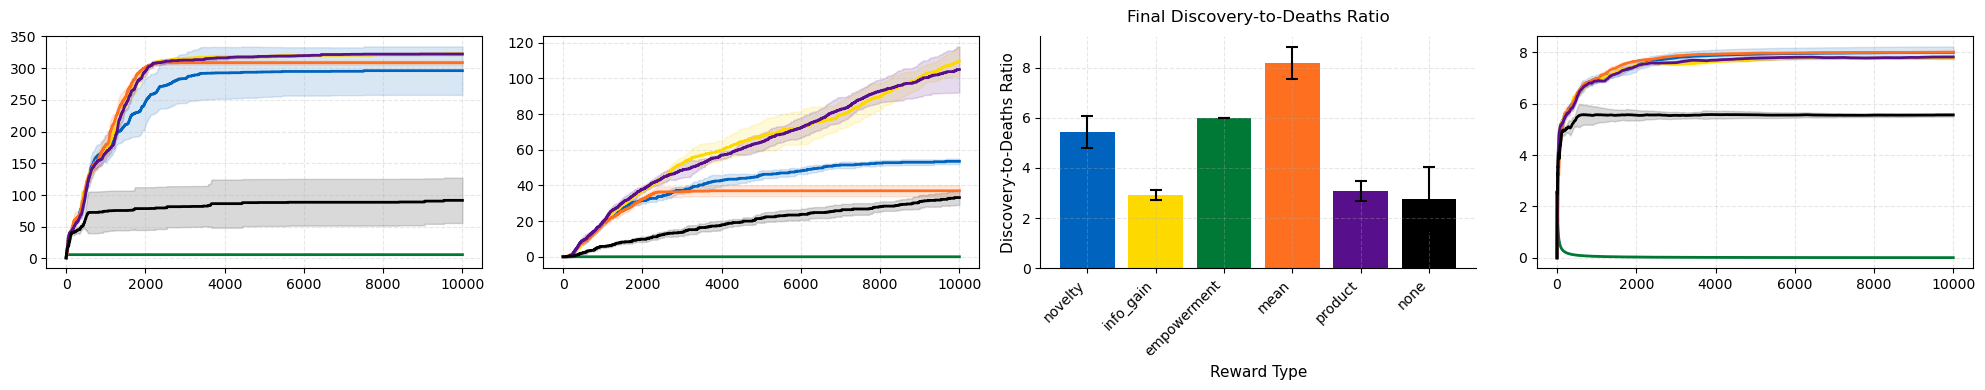

In [ ]:
plot_learning_curves_with_variance(analyzed_data, save_path="../fig/new/")

In [ ]:
plot_learning_curves_with_variance(analyzed_data, save_path="../fig/long_run/")

In [ ]:
results.keys()

In [ ]:
plot_learning_curves_with_variance(analyzed_data)
plt.show()

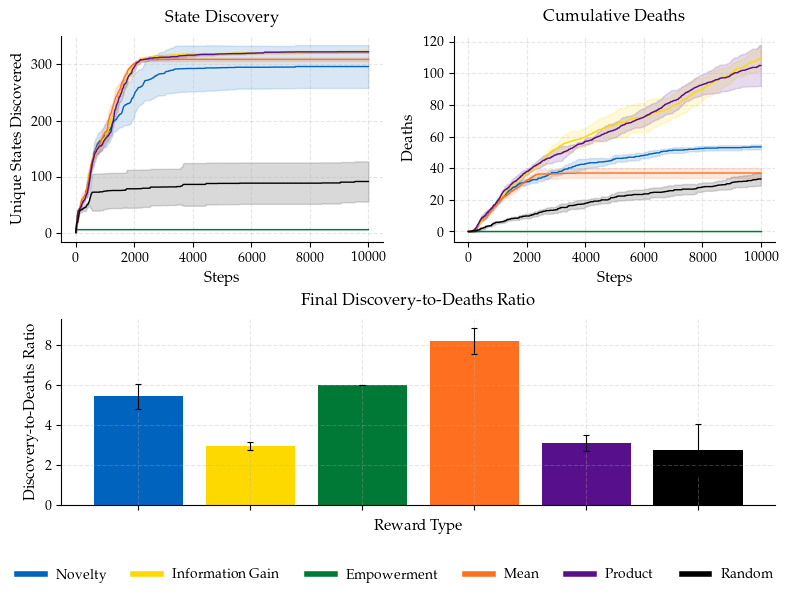

In [40]:
plot_learning_curves_with_variance2(analyzed_data, save_path="../fig/tabular/", subsample=True)
plt.show()

In [39]:
import os
import matplotlib.pyplot as plt
import numpy as np

LABELS_TO_NICE_NAMES = {
    'none': 'Random',
    'novelty': 'Novelty',
    'info_gain': 'Information Gain',
    'empowerment': 'Empowerment',
    'mean': 'Mean',
    'product': 'Product'
}

def plot_learning_curves_with_variance2(analyzed_data, save_path="figures", subsample=False):
    """Plot learning curves with mean and standard deviation across seeds, optimized for single-column paper format."""
    
    reward_results = analyzed_data['reward_results']
    ordered_rewards = analyzed_data['ordered_rewards']
    
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Set figure style for publication using matplotlib
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams.update({
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        "text.usetex": True,
        "font.family": "Palatino"
    })
    
    fig_combined = plt.figure(figsize=(8, 6))  # Slightly taller to accommodate legend
    
    # Create a custom gridspec with room for legend at bottom
    gs = fig_combined.add_gridspec(2, 2, height_ratios=[1, 0.9])
    
    # Create axes - top row has two plots, bottom row has one centered plot
    ax1 = fig_combined.add_subplot(gs[0, 0])
    ax2 = fig_combined.add_subplot(gs[0, 1])
    ax3 = fig_combined.add_subplot(gs[1, :])  # Spans both columns
    
    color_map = {
        'none': '#000000',
        'novelty': '#0063be',
        'info_gain': '#fed900',
        'empowerment': '#007836',
        'mean': '#ff6f20',
        'product': '#580f8b'
    }
    
    # Plot in specific order
    labels = []
    final_ratios = []
    final_stds = []
    legend_handles = []
    
    for reward_str in ordered_rewards:
        if reward_str not in reward_results:
            continue
            
        stats, params = reward_results[reward_str]
        color = color_map[reward_str]
        x = np.arange(len(stats['states_mean']))
        
        if subsample:
            indices = np.linspace(0, len(stats['states_mean'])-1, 1000, dtype=int)
            
            # Downsample all data arrays
            states_mean = stats['states_mean'][indices]
            states_std = stats['states_std'][indices]
            deaths_mean = stats['deaths_mean'][indices]
            deaths_std = stats['deaths_std'][indices]
            x = x[indices]
        else:
            states_mean = stats['states_mean']
            states_std = stats['states_std']
            deaths_mean = stats['deaths_mean']
            deaths_std = stats['deaths_std']
        
        # Plot first two subplots
        for ax, data_mean, data_std, title, ylabel in [
            (ax1, states_mean, states_std, 'State Discovery', 'Unique States Discovered'),
            (ax2, deaths_mean, deaths_std, 'Cumulative Deaths', 'Deaths'),
        ]:
            if subsample:
                # Before plotting, downsample large datasets to 1000 points
                if len(data_mean) > 1000:
                    indices = np.linspace(0, len(data_mean) - 1, 1000).astype(int)
                    data_mean = data_mean[indices]
                    data_std = data_std[indices]
                    x = np.arange(len(data_mean))

            line, = ax.plot(x, data_mean, color=color, linewidth=1)
            ax.fill_between(x, data_mean - data_std, data_mean + data_std, alpha=0.15, color=color)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(labelsize=10)
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_xlabel('Steps', fontsize=11)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(title, fontsize=12, pad=10)
            
            if ax == ax1:  # Only store handles from the first plot for the legend
                legend_handles.append(line)
        
        # Store data for bar plot
        labels.append(reward_str)
        final_ratios.append(stats['states_to_death_ratios_mean'][-1])
        final_stds.append(stats['states_to_death_ratios_std'][-1])
    
    # Bar plot
    x_pos = np.arange(len(labels))
    bars = ax3.bar(x_pos, final_ratios, yerr=final_stds, 
                   capsize=2, 
                   color=[color_map[label] for label in labels],
                   error_kw={'elinewidth': 0.8, 'capthick': 0.8})
    ax3.set_xticks(x_pos)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.set_xlabel('Reward Type', fontsize=11)
    ax3.set_ylabel('Discovery-to-Deaths Ratio', fontsize=11)
    ax3.set_title('Final Discovery-to-Deaths Ratio', fontsize=12, pad=10)
    
    # Remove x-ticks for cleaner look
    ax3.set_xticklabels([])
    
    # Add horizontal legend at the bottom of the figure
    legend = fig_combined.legend(
        handles=legend_handles,
        labels=[LABELS_TO_NICE_NAMES[label] for label in labels],
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.00),
        ncol=len(labels),  # Horizontal layout
        frameon=False,
        fontsize=10,
    )

    # make lines in legend thicker
    for line in legend.get_lines():
        line.set_linewidth(4.0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Adjust layout to make room for the legend
    plt.subplots_adjust(bottom=0.15)
    
    # Save combined figure
    fig_combined.savefig(os.path.join(save_path, 'combined_plots.pdf'), 
                        dpi=300, 
                        bbox_inches='tight',
                        pad_inches=0.1)
    
    return fig_combined